In [1]:
import pandas as pd
from Bio import SeqIO
import sys
import os
from ast import literal_eval
import numpy as np


import pybedtools
from pybedtools import BedTool


#For plotting
from matplotlib.colors import LinearSegmentedColormap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#For statistics
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import itertools

import re
from Bio import SeqIO
import ast # for safe eveal, for parsing some of the data
import math
os.chdir('/home/labs/davidgo/nadavmi/backup')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
#from const import MPRA_data_paths
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
const.set_plot_style()
import matplotlib.ticker as mtick


# This function receives a dataframe, coordinates columns, source assembly and target assembly. It lifts over the coords and adds lifted coords to the df.
# assuming coords are 1-based.
os.chdir('/home/labs/davidgo/Collaboration/Lab_Tools/liftOver/no_GUI')
from liftOver import initializer as initializer
from liftOver import liftOver_df as liftOver

os.chdir('/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures')

output_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/'

/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


# Adjusting the P-values of the selection test, to account for the multiple testing of GAG-related pathways. 

In [3]:
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Original P values
p_values = [0.007451985, 0.007011986, 0.258955482, 0.004413991]
pathway_ids = ["hsa00532", "hsa00534", "hsa00533", "hsa00531"]
pathway_names = [
    "Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate",
    "Glycosaminoglycan biosynthesis - heparan sulfate / heparin",
    "Glycosaminoglycan biosynthesis - keratan sulfate",
    "Glycosaminoglycan degradation"
]

# Apply FDR correction (Benjamini-Hochberg method)
reject, adj_pvalues, _, _ = multipletests(p_values, method='fdr_bh')

# Create results dataframe
results = pd.DataFrame({
    'Pathway ID': pathway_ids,
    'Pathway Name': pathway_names,
    'Original P-value': p_values,
    'FDR-adjusted P-value': adj_pvalues,
    'Significant (α=0.05)': reject
})

print("FDR-Adjusted P-values (Benjamini-Hochberg method):")
print(results.to_string(index=False))


FDR-Adjusted P-values (Benjamini-Hochberg method):
Pathway ID                                                            Pathway Name  Original P-value  FDR-adjusted P-value  Significant (α=0.05)
  hsa00532 Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate          0.007452              0.009936                  True
  hsa00534              Glycosaminoglycan biosynthesis - heparan sulfate / heparin          0.007012              0.009936                  True
  hsa00533                        Glycosaminoglycan biosynthesis - keratan sulfate          0.258955              0.258955                 False
  hsa00531                                           Glycosaminoglycan degradation          0.004414              0.009936                  True


In [7]:
df

,pathway ID,last_value,p_value,L,p_adj,reject_fdr_0.05
0,path:hsa04142,-11.723915,0.000674,333,0.173224,False
1,path:hsa00591,-3.513214,0.001188,29,0.173224,False
2,path:hsa00590,-5.182122,0.001468,75,0.173224,False
3,path:hsa00531,-3.416069,0.004414,39,0.329750,False
4,path:hsa03264,-1.085875,0.005672,1,0.329750,False
...,...,...,...,...,...,...
349,path:hsa05210,0.052125,0.986326,265,0.993206,False
350,path:hsa00740,0.010116,0.987160,6,0.993206,False
351,path:hsa00380,0.022255,0.987892,73,0.993206,False
352,path:hsa00120,0.008228,0.990400,13,0.993206,False


In [18]:
# Load the dataset
dataset_path = "/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/analysis_results_idan_selection_test.csv"
df = pd.read_csv(dataset_path)

# Filter for the four pathways (with path: prefix)
pathways_to_filter = ["path:hsa00532", "path:hsa00534", "path:hsa00533", "path:hsa00531"]
df_filtered = df[df['pathway ID'].isin(pathways_to_filter)].copy()

# Calculate FDR only on these four pathways
from statsmodels.stats.multitest import multipletests
reject, fdr_values, _, _ = multipletests(df_filtered['p_value'], method='fdr_bh')

# Add FDR as a new column
df_filtered['FDR'] = fdr_values

df_filtered = df_filtered[['pathway ID','L', 'p_value', 'FDR']]

print("Filtered dataset with FDR (calculated on these 4 pathways only):")
print(df_filtered)

Filtered dataset with FDR (calculated on these 4 pathways only):
       pathway ID    L   p_value       FDR
3   path:hsa00531   39  0.004414  0.009936
6   path:hsa00534   56  0.007012  0.009936
7   path:hsa00532  100  0.007452  0.009936
94  path:hsa00533   39  0.258955  0.258955


In [19]:
# Save the filtered dataframe with FDR to CSV
output_csv_path = '/home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/selection_test_filtered_pathways_with_fdr.csv'
df_filtered.to_csv(output_csv_path, index=False)
print(f"Dataset saved to: {output_csv_path}")

Dataset saved to: /home/labs/davidgo/Collaboration/humanMPRA/paper/extended_datasets/selection_test_filtered_pathways_with_fdr.csv


# Fisher's exact for active oligos X chondrocyte active chromatin


#### 3) The MPRA library was filtered for being in regulatory elements (i.e., SCREEN), but I believe this regulatory signal could have come from tissues/cells unrelated to chondrocytes. The main text does say that the MPRA-positive fragments in the library tend to overlap open chromatin, but I am curious about the exact numbers of MPRA-positive/negative elements that do/don't overlap open chromatin. Would MPRA-positive fragments in closed chromatin be considered false positives (in the context of the MPRA experiment)?

In [2]:
# Read only the specified columns from the CSV file
oligos = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', 
                     #usecols=range(0, 25), 
                     header=0)
print('Number of oligos in hMPRA:', len(oligos))
oligos = oligos.drop_duplicates(subset=["oligo"], keep = "first") #There are several HH oligos which are duplicated
print('Number of oligos in hMPRA without duplicates:', len(oligos))

min_DNA_counts = 50

oligos = oligos[(oligos['DNA_counts_raw_derived']>min_DNA_counts) &
                               (oligos['DNA_counts_raw_ancestral']>min_DNA_counts)]
print('Number of oligos in hMPRA after filtering for at least 50 DNA counts in both archaic and derived:', len(oligos))


/tmp/ipykernel_3855591/2327027152.py:2: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  oligos = pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv',


Number of oligos in hMPRA: 355898
Number of oligos in hMPRA without duplicates: 355891
Number of oligos in hMPRA after filtering for at least 50 DNA counts in both archaic and derived: 313358


In [24]:
oligos.columns

Index(['oligo', 'RNA_DNA_ratio_log2_ancestral', 'RNA_DNA_ratio_log2_derived',
       'DNA_counts_raw_ancestral', 'DNA_counts_raw_derived',
       'barcode_count_ancestral', 'barcode_count_derived',
       'normalized_activity_estimate_ancestral',
       'normalized_activity_estimate_derived', 'activity_fdr_ancestral',
       'activity_fdr_derived', 'activity_ancestral', 'activity_derived',
       'logFC_derived_vs_ancestral', 'differential_activity_fdr',
       'differential_activity', 'id', 'variants_count', 'variants_genomic',
       'chromosome', 'start', 'end', 'region_id', 'NCBI_Gene_ID',
       'Gene_symbol', 'Distance_to_gene(TSS)', 'closest_gene',
       'within_promoter', 'eRNA', 'eQTL', 'HiC', 'num_sources_linking_gene',
       'Num_associated_genes', 'Min Dis Tracks', 'Min Dis Values',
       'Pos_Sel_ModHum_vs_ArcHum1', 'Pos_Sel_ModHum_vs_ArcHum2',
       'Pos_Sel_Hum_HKA', 'Pos_Sel_Hum_FWH', 'Merged_Pos_Sel', 'linARs',
       'HACNS', 'HARs', 'Modern Derived DMRs', 'Archai

In [28]:
oligos['ATACseq_peaks_fetal_chondrocytes']

0             0
1          -943
2             0
3         10755
4         -2263
          ...  
355893        0
355894        0
355895        0
355896        0
355897      -29
Name: ATACseq_peaks_fetal_chondrocytes, Length: 313358, dtype: int64

In [4]:
from scipy.stats import fisher_exact

# Step 1: Define activity status
# NA = not active, true/false = active
oligos['activity_status'] = oligos['differential_activity'].apply(
    lambda x: 'Not Active' if pd.isna(x) else 'Active'
)

oligos['chromatin_state'] = oligos.apply(
    lambda row: 'Closed' if (
        row['ATACseq_peaks_fetal_chondrocytes'] != 0 and
        row['H3K27Ac_peaks_fetal_chondrocytes'] != 0
    ) else 'Open',
    axis=1
)

# Step 2: Define chromatin state
# 0 = open chromatin, non-0 = closed chromatin
#oligos['chromatin_state'] = oligos['ATACseq_peaks_fetal_chondrocytes'].apply(
#    lambda x: 'Open' if x == 0 else 'Closed'
#)

# Step 3: Create contingency table
contingency_table = pd.crosstab(
    oligos['activity_status'], 
    oligos['chromatin_state'],
    margins=True
)

print("Contingency Table: Active/Non-Active Oligos X Open/Close Chromatin")
print("="*60)
print(contingency_table)
print("\n")

# Step 4: Extract 2x2 table for Fisher's exact test
# Remove margins row and column
table_2x2 = pd.crosstab(oligos['activity_status'], oligos['chromatin_state'])
print("2x2 Contingency Table (without margins):")
print(table_2x2)
print("\n")

# Step 5: Apply Fisher's exact test
oddsratio, p_value = fisher_exact(table_2x2)

print("Fisher's Exact Test Results:")
print("="*60)
print(f"Odds Ratio: {oddsratio:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")


Contingency Table: Active/Non-Active Oligos X Open/Close Chromatin
chromatin_state  Closed    Open     All
activity_status                        
Active            23374   28658   52032
Not Active       177129   84197  261326
All              200503  112855  313358


2x2 Contingency Table (without margins):
chromatin_state  Closed   Open
activity_status               
Active            23374  28658
Not Active       177129  84197


Fisher's Exact Test Results:
Odds Ratio: 0.3877
P-value: 0.0000e+00
Significant at α=0.05: Yes


In [ ]:
import sys
import numpy as np

# Get the actual raw p_value
print(f"Exact P-value with full precision: {p_value}")
print(f"P-value represented in bits: {p_value.hex() if hasattr(p_value, 'hex') else 'N/A'}")
print(f"\nSmallest positive float Python can represent: {sys.float_info.min}")

# Try to get log p-value for better precision handling
from scipy.stats import fisher_exact
log_pval = np.log10(p_value) if p_value > 0 else "P-value is exactly 0 or below machine precision"
print(f"\nLog10(P-value): {log_pval}")

# The p-value is so extreme it underflows to 0.0
# This means P-value < 1e-308 (the smallest positive float64)
print(f"\nConclusion: The P-value is smaller than the smallest positive float")
print(f"that can be represented (< {sys.float_info.min})")
print(f"Report: P-value < 1e-308")

# Improve upon Noi's analysis

In [5]:
pwd

'/home/labs/davidgo/Collaboration/backup/humanMPRA/scripts/produce_paper_figures'

In [2]:
gwas_data = pd.read_csv("/home/labs/davidgo/noic/hd_project/data/gwas/gwas_gene_ranking/gene_trait_rankings_all_ranked.csv")
oa_data = gwas_data[gwas_data['ORIGINAL_TRAIT']=='osteoarthritis']
oa_data_leveled = oa_data[oa_data['rank_level'].isin(['HIGH', 'MEDIUM'])].copy()
oa_genes = oa_data_leveled['Gene_symbol'].unique()

In [3]:
kegg_data = pd.read_csv("/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Gene_Lists/KEGG/kegg_human_pathway_to_gene_symbol.tsv", sep='\t')


Pathways with >= 20 genes: 335
Total pathways: 371

Glycosaminoglycan biosynthesis - heparan sulfate
  Total genes: 24
  OA genes overlap: 1
  Enrichment: 4.17%

Glycosaminoglycan biosynthesis - chondroitin sulfate
  Total genes: 21
  OA genes overlap: 2
  Enrichment: 9.52%

Glycosaminoglycan degradation
  Total genes: 19
  OA genes overlap: 3
  Enrichment: 15.79%

Glycosaminoglycan biosynthesis - keratan sulfate
  Total genes: 14
  OA genes overlap: 2
  Enrichment: 14.29%



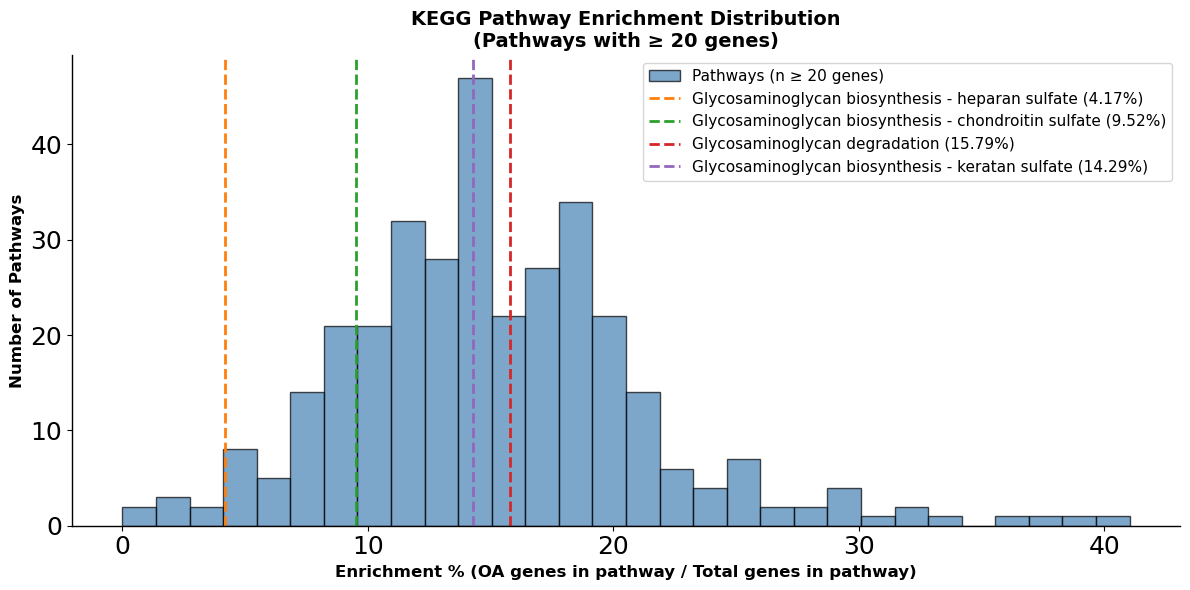


Histogram saved to: /home/labs/davidgo/Collaboration/humanMPRA/paper/raw_plots/kegg_enrichment_histogram.png


In [4]:
# =====================================================
# KEGG Pathway Enrichment Analysis for OA Genes
# =====================================================

# Step 1: Calculate enrichment statistics for each pathway
enrichment_results = []

for pathway_name in kegg_data['pathway_name'].unique():
    pathway_genes = kegg_data[kegg_data['pathway_name'] == pathway_name]['gene_symbol'].unique()
    total_genes = len(pathway_genes)

    oa_genes_in_pathway = np.intersect1d(pathway_genes, oa_genes)
    oa_genes_count = len(oa_genes_in_pathway)

    percentage = (oa_genes_count / total_genes * 100) if total_genes > 0 else 0

    enrichment_results.append({
        'pathway_name': pathway_name,
        'total_genes': total_genes,
        'oa_genes_count': oa_genes_count,
        'enrichment_percent': percentage
    })

enrichment_df = pd.DataFrame(enrichment_results)
enrichment_df = enrichment_df.sort_values('enrichment_percent', ascending=False).reset_index(drop=True)

enrichment_df['oa_genes_list'] = enrichment_df['pathway_name'].apply(
    lambda pathway: list(np.intersect1d(
        kegg_data[kegg_data['pathway_name'] == pathway]['gene_symbol'].unique(),
        oa_genes
    ))
)

# Step 2: Filter pathways with at least 20 genes for histogram
MIN_GENES = 20
enrichment_df_filtered = enrichment_df[enrichment_df['total_genes'] >= MIN_GENES].copy()

print(f"Pathways with >= {MIN_GENES} genes: {len(enrichment_df_filtered)}")
print(f"Total pathways: {len(enrichment_df)}\n")

# Pathways to highlight
target_pathways = [
    "Glycosaminoglycan biosynthesis - heparan sulfate",
    "Glycosaminoglycan biosynthesis - chondroitin sulfate",
    "Glycosaminoglycan degradation",
    "Glycosaminoglycan biosynthesis - keratan sulfate",
]

# Report target pathways
for name in target_pathways:
    row = enrichment_df[enrichment_df['pathway_name'].str.contains(name, case=False, na=False)]
    if len(row) > 0:
        pct = row['enrichment_percent'].values[0]
        total = row['total_genes'].values[0]
        overlap = row['oa_genes_count'].values[0]
        print(f"{name}")
        print(f"  Total genes: {total}")
        print(f"  OA genes overlap: {overlap}")
        print(f"  Enrichment: {pct:.2f}%\n")
    else:
        print(f"WARNING: '{name}' not found in kegg_data\n")

# Step 3: Create histogram
fig, ax = plt.subplots(figsize=(12, 6))

n, bins, patches = ax.hist(
    enrichment_df_filtered['enrichment_percent'],
    bins=30,
    color='steelblue',
    alpha=0.7,
    edgecolor='black',
    label=f'Pathways (n ≥ {MIN_GENES} genes)'
)

# Add vertical lines for target pathways
colors = ['C1', 'C2', 'C3', 'C4']
for name, col in zip(target_pathways, colors):
    row = enrichment_df[enrichment_df['pathway_name'].str.contains(name, case=False, na=False)]
    if len(row) > 0:
        pct = row['enrichment_percent'].values[0]
        ax.axvline(pct, color=col, linestyle='--', linewidth=2, label=f"{name} ({pct:.2f}%)")

ax.set_xlabel('Enrichment % (OA genes in pathway / Total genes in pathway)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Pathways', fontsize=12, fontweight='bold')
ax.set_title(f'KEGG Pathway Enrichment Distribution\n(Pathways with ≥ {MIN_GENES} genes)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig(output_path + 'kegg_enrichment_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nHistogram saved to: {output_path}kegg_enrichment_histogram.png")


In [47]:
enrichment_df

,pathway_name,total_genes,oa_genes_count,enrichment_percent,oa_genes_list
0,Riboflavin metabolism,8,4,50.000000,"[ACP1, ACP2, ENPP1, FLAD1]"
1,Virion - Rotavirus,2,1,50.000000,[ITGA2]
2,Allograft rejection,39,16,41.025641,"[CD80, HLA-B, HLA-C, HLA-DMA, HLA-DMB, HLA-DOA..."
3,Type I diabetes mellitus,44,17,38.636364,"[CD80, HLA-B, HLA-C, HLA-DMA, HLA-DMB, HLA-DOA..."
4,Asthma,32,12,37.500000,"[HLA-DMA, HLA-DMB, HLA-DOA, HLA-DOB, HLA-DPA1,..."
...,...,...,...,...,...
366,C5-Branched dibasic acid metabolism,2,0,0.000000,[]
367,Selenocompound metabolism,17,0,0.000000,[]
368,Ascorbate and aldarate metabolism,31,0,0.000000,[]
369,Virion - Flavivirus and Alphavirus,6,0,0.000000,[]


In [43]:
enrichment_df[enrichment_df['pathway_name'].str.contains('Glycosaminoglycan', case=False, na=False)]

,pathway_name,total_genes,oa_genes_count,enrichment_percent,oa_genes_list
84,Glycosaminoglycan biosynthesis - keratan sulfate,14,1,7.142857,[ST3GAL2]
183,Glycosaminoglycan biosynthesis - chondroitin s...,21,1,4.761905,[CHST3]
358,Glycosaminoglycan degradation,19,0,0.000000,[]
360,Glycosaminoglycan biosynthesis - heparan sulfa...,24,0,0.000000,[]


In [29]:
enrichment_df.sort_values('enrichment_percent', ascending=False).query('total_genes >= 20')

,pathway_name,total_genes,oa_genes_count,enrichment_percent
2,Allograft rejection,39,16,41.025641
3,Type I diabetes mellitus,44,17,38.636364
4,Asthma,32,12,37.500000
6,Graft-versus-host disease,45,16,35.555556
7,Autoimmune thyroid disease,54,18,33.333333
...,...,...,...,...
359,Olfactory transduction,449,12,2.672606
360,Nicotine addiction,41,1,2.439024
361,Porphyrin metabolism,46,1,2.173913
368,Ascorbate and aldarate metabolism,31,0,0.000000
